In [ ]:
import numpy as np
import os
from PIL import Image
import scipy
from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA
import torch
import torch.nn as nn
import torchvision
from torchvision import transforms
from torchvision.utils import make_grid
import torch.nn.functional as F
import torchvision.transforms as T
import io, base64
from tqdm.notebook import tqdm
from IPython.display import display, update_display
from matplotlib import  pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.graph_objs import FigureWidget
import plotly.express as px
import warnings
from google.colab import output
output.enable_custom_widget_manager()

sns.set_theme(style="darkgrid")
warnings.filterwarnings("ignore")

from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


### Forward process

In [ ]:
def get_beta_schedule(schedule_type, T, beta_start=1e-4, beta_end=0.02):
    if schedule_type == "linear":
        return torch.linspace(beta_start, beta_end, T)
    elif schedule_type == "cosine":
        steps = T + 1
        x = torch.linspace(0, T, steps) / T
        alphas = torch.cos(x * np.pi * 0.5) ** 2
        alphas = alphas / alphas[0]
        betas = 1 - (alphas[1:] / alphas[:-1])
        return torch.clip(betas, 0.0001, 0.9999)
    elif schedule_type == "fixed":
        return torch.full((T,), beta_end)

In [ ]:
class Diffusion:
    def __init__(self, model, T=1000, schedule_type="linear", device="cuda"):
        self.model = model
        self.T = T
        self.device = device

        self.betas = get_beta_schedule(schedule_type, self.T).to(device)
        self.alphas = (1. - self.betas).to(device)
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0).to(device)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]])

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod).to(device)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod).to(device)

    def q_sample(self, x_start, t, noise=None):
        """Perform forward procces, adding noise to image"""
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_alpha_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alpha_cumprod_t * x_start + sqrt_one_minus_alpha_cumprod_t * noise

    def p_losses(self, x_0, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        x_noisy = self.q_sample(x_0, t, noise)
        noise_pred = self.model(x_noisy, t)
        return F.mse_loss(noise_pred, noise)

    def visualize_forward_process(self, x_start, device=None, num_images=10):
        """Visualization of adding noise to image"""
        if device is None:
          device = self.device
        x_start = x_start.to(device)
        fig, axs = plt.subplots(1, num_images, figsize=(15, 3))
        step_size = int(self.T / num_images)
        # for i, step in enumerate(steps):
        for i, step in enumerate(range(0, self.T, step_size)):
            t = torch.full((x_start.shape[0],), step, device=device, dtype=torch.long)
            noisy = self.q_sample(x_start, t)
            img = noisy[0].detach().cpu().permute(1, 2, 0)
            axs[i].imshow(img.clip(0, 1), cmap="grey")
            axs[i].set_title(f"t = {step}")
            axs[i].axis("off")
        plt.tight_layout()
        plt.show()

    @torch.no_grad()
    def sample(self, n=16, img_size=(1, 28, 28), device=None):
        """Get image samples"""
        if device is None:
          device = self.device
        img = torch.randn((n, *img_size)).to(device)

        for i in reversed(range(self.T)):
            t = torch.full((n,), i, dtype=torch.long).to(device)
            beta_t = self.betas[t].view(-1, 1, 1, 1).to(device)
            alpha_t = self.alphas[t].view(-1, 1, 1, 1).to(device)
            alpha_cumprod_t = self.alphas_cumprod[t].view(-1, 1, 1, 1).to(device)
            alpha_cumprod_prev_t = self.alphas_cumprod_prev[t].view(-1, 1, 1, 1).to(device)

            noise_pred = self.model(img, t)
            if i > 0:
                noise = torch.randn_like(img)
            else:
                noise = torch.zeros_like(img)

            coef1 = 1 / alpha_t.sqrt()
            coef2 = (1 - alpha_t) / (1 - alpha_cumprod_t).sqrt()
            mean = coef1 * (img - coef2 * noise_pred)
            var = beta_t.sqrt()

            img = mean + var * noise

        return img

### U-Net

In [ ]:
def get_sinusoidal_embedding(timesteps, dim):
    device = timesteps.device
    half_dim = dim // 2
    emb = np.log(10000) / (half_dim - 1)
    emb = torch.exp(torch.arange(half_dim, dtype=torch.float32, device=device) * -emb)
    emb = timesteps[:, None].float() * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    return emb


class ResBlock(nn.Module):
    def __init__(self, in_channels, out_channels, time_emb_dim, dropout=0.1):
        super().__init__()
        self.norm1 = nn.GroupNorm(8, in_channels)
        self.act1 = nn.ReLU()
        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)

        self.norm2 = nn.GroupNorm(8, out_channels)
        self.act2 = nn.ReLU()
        self.dropout = nn.Dropout(dropout)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)

        self.time_mlp = nn.Sequential(
            nn.ReLU(),
            nn.Linear(time_emb_dim, out_channels)
        )

        if in_channels != out_channels:
            self.residual_conv = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.residual_conv = nn.Identity()

    def forward(self, x, t_emb):
        h = self.conv1(self.act1(self.norm1(x)))
        time_emb = self.time_mlp(t_emb).unsqueeze(-1).unsqueeze(-1)
        h = h + time_emb
        h = self.conv2(self.dropout(self.act2(self.norm2(h))))
        return h + self.residual_conv(x)


class SelfAttention(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.norm = nn.GroupNorm(8, channels)
        self.qkv = nn.Conv1d(channels, channels * 3, 1)
        self.proj_out = nn.Conv1d(channels, channels, 1)

    def forward(self, x):
        B, C, H, W = x.shape
        x_ = self.norm(x).reshape(B, C, H * W)
        qkv = self.qkv(x_)
        q, k, v = qkv.chunk(3, dim=1)
        attn = torch.softmax(torch.bmm(q.transpose(1, 2), k) / np.sqrt(C), dim=-1)
        out = torch.bmm(attn, v.transpose(1, 2)).transpose(1, 2)
        out = self.proj_out(out).reshape(B, C, H, W)
        return x + out


class Downsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.Conv2d(channels, channels, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


class Upsample(nn.Module):
    def __init__(self, channels):
        super().__init__()
        self.conv = nn.ConvTranspose2d(channels, channels, 4, 2, 1)

    def forward(self, x):
        return self.conv(x)


In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=64, time_emb_dim=256, attention_resolutions=[16]):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(time_emb_dim, time_emb_dim * 4),
            nn.ReLU(),
            nn.Linear(time_emb_dim * 4, time_emb_dim)
        )

        # Input layer
        self.init_conv = nn.Conv2d(in_channels, base_channels, 3, padding=1)

        # Encoder
        self.downs = nn.ModuleList()
        channels = base_channels
        resolutions = [32, 16, 8]
        for res in resolutions:
            block = nn.ModuleList([
                ResBlock(channels, channels, time_emb_dim),
                ResBlock(channels, channels, time_emb_dim)
            ])
            if res in attention_resolutions:
                block.append(SelfAttention(channels))
            self.downs.append(block)
            if res != resolutions[-1]:
                self.downs.append(Downsample(channels))

        # Bottleneck
        self.bot1 = ResBlock(channels, channels, time_emb_dim)
        self.bot_attn = SelfAttention(channels)
        self.bot2 = ResBlock(channels, channels, time_emb_dim)

        # Decoder
        self.ups = nn.ModuleList()
        for res in reversed(resolutions):
            block = nn.ModuleList([
                ResBlock(channels * 2, channels, time_emb_dim),
                ResBlock(channels, channels, time_emb_dim)
            ])
            if res in attention_resolutions:
                block.append(SelfAttention(channels))
            self.ups.append(block)
            if res != resolutions[0]:
                self.ups.append(Upsample(channels))

        self.final_norm = nn.GroupNorm(8, channels)
        self.final_act = nn.ReLU()
        self.final_conv = nn.Conv2d(channels, out_channels, 3, padding=1)

    def forward(self, x, t):
        t = t.to(x.device)
        t_emb = get_sinusoidal_embedding(t, self.time_mlp[0].in_features).to(x.device)
        t_emb = t_emb.to(self.time_mlp[0].weight.device)
        t_emb = self.time_mlp(t_emb)

        x = self.init_conv(x)
        skip_connections = []

        for block in self.downs:
            if isinstance(block, nn.ModuleList):
                for layer in block:
                    x = layer(x, t_emb) if isinstance(layer, ResBlock) else layer(x)
                skip_connections.append(x)
            else:
                x = block(x)

        x = self.bot1(x, t_emb)
        x = self.bot_attn(x)
        x = self.bot2(x, t_emb)

        for block in self.ups:
            if isinstance(block, nn.ModuleList):
                skip = skip_connections.pop()
                x = torch.cat([x, skip], dim=1)
                for layer in block:
                    x = layer(x, t_emb) if isinstance(layer, ResBlock) else layer(x)
            else:
                x = block(x)

        return self.final_conv(self.final_act(self.final_norm(x)))

### Визуализация

In [ ]:
def create_plot_widget():
    # Виджет в plotly для вывода интерактивных графиков для обучения модели
    fig = make_subplots(rows=1, cols=2, shared_xaxes=False, horizontal_spacing=0.1, vertical_spacing=0.12,
                        subplot_titles=["U-Net Loss", "Generated Images"],
                        specs=[
                          [{}, {}]]
    )

    trace_gen_loss = go.Scatter(name="MSELoss", line=dict(color="blue"), legendgroup=1)

    fig.add_trace(trace_gen_loss, row=1, col=1)


    fig.update_layout(height=550, width=1100, title="Diffusion Model Training Progress",
                      xaxis1=dict(title="Epoch"),
                      yaxis1=dict(title="MSELoss"),
                      legend=dict(
                          orientation="h",
                          yanchor="bottom",
                          y=-0.3,
                          xanchor="center",
                          x=0.33
                      ),
                      xaxis2=dict(
                          range=[-1, 1],
                          zeroline=False,
                          showticklabels=False,
                          title=None,
                          showgrid=False,
                          fixedrange=True,
                      ),
                      yaxis2=dict(
                          range=[-1, 1],
                          zeroline=False,
                          showticklabels=False,
                          title=None,
                          showgrid=False,
                          fixedrange=True,
                          scaleanchor="x3",
                      ),
    )
    for i in range(1, 3):
        fig.update_layout({
            f"xaxis{i}": dict(title_standoff=5, automargin=True),
            f"yaxis{i}": dict(title_standoff=5, automargin=True, scaleanchor=f'x{i}', scaleratio=1)
        })

    fig.update_xaxes(showgrid=False, visible=False, row=1, col=2)
    fig.update_yaxes(showgrid=False, visible=False, row=1, col=2)

    # fig.add_shape(
    #     type="rect",
    #     xref="paper", yref="paper",
    #     x0=0.7, x1=1.0,
    #     y0=0.0, y1=1.0,
    #     fillcolor="white",
    #     layer="below",
    #     line_width=0
    # )
    fig.add_shape(
        type="rect",
        xref="x2",
        yref="y2",
        x0=-1.5, x1=1.5,
        y0=-1.5, y1=1.5,
        fillcolor="white",
        layer="below",
        line_width=0
    )

    fig_widget = FigureWidget(fig)
    return fig_widget

In [ ]:
def generate_sample(diffusion, sample_size=64):
    """Generation from latent space"""
    diffusion.model.to(device)
    diffusion.model.eval()
    with torch.no_grad():
        sample = diffusion.sample(sample_size, (1, 28, 28))
        img_grid = make_grid(sample, nrow=int(np.sqrt(sample_size)), normalize=True)
        return img_grid


def tensor_to_image(tensor):
    tensor = tensor.detach().cpu()
    tensor = tensor.permute(1, 2, 0)
    array = (tensor * 255).clamp(0, 255).byte().numpy()
    return Image.fromarray(array, mode='RGB')


def visualize_plt_sample(diffusion, img_count=64):
    plt.imshow(generate_sample(diffusion, img_count).cpu().permute(1, 2, 0))
    plt.grid(False)
    plt.axis("off")
    plt.show()

In [ ]:
def update_plot_widget(fig_widget, losses, gen_img_tensor):
    # Обновление данных на виджете
    x = list(range(len(losses)))

    with fig_widget.batch_update():
        fig_widget.data[0].x = x
        fig_widget.data[0].y = losses

        # визуализация сгенерированных изображений
        if gen_img_tensor is not None:
            gen_img_go = dict(
                    source=tensor_to_image(gen_img_tensor),
                    xref="x2",
                    yref="y2",
                    x=1,
                    y=-1,
                    sizex=2,
                    sizey=2,
                    xanchor="right",
                    yanchor="bottom",
                    layer="above"
            )
            fig_widget.update_layout(
                title=f"Diffusion Model Training Progress — Epoch {len(x) - 1}",
                images = [gen_img_go],
            )

In [ ]:
import os
from torchvision.utils import save_image

def save_image_epoch(img_tensor, epoch, model_title="unet"):
    save_dir = f"/content/drive/MyDrive/Models_images/{model_title}"
    os.makedirs(save_dir, exist_ok=True)
    file_path = os.path.join(save_dir, f"{model_title}_epoch_{epoch}.png")
    save_image(img_tensor, file_path, normalize=True)

### Инфраструктура

In [ ]:
def save_model_state(model, optimiser, model_title, epoch_num):
    # Сохранение состояния модели
    torch.save({
            'epoch': epoch_num,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimiser.state_dict()
            }, os.path.join("/content/drive/MyDrive/model_states", f"{model_title}_{epoch_num}.pt"))


def load_model_state(model, model_title, optimiser=None):
    # Загрузка состояния модели
    checkpoint = torch.load(os.path.join("/content/drive/MyDrive/model_states", f"{model_title}.pt"),
                            map_location=torch.device('cuda') if torch.cuda.is_available() else torch.device("cpu"))
    model.load_state_dict(checkpoint['model_state_dict'])
    if optimiser is not None:
        optimiser.load_state_dict(checkpoint['optimizer_state_dict'])
    epoch = checkpoint["epoch"]
    return epoch

In [ ]:
def train(data_loader, diffusion,  model, optim, num_epochs, model_title="unet", img_count=64):
    """Diffusion model training"""
    losses_epochs = []
    fig_widget = create_plot_widget()
    display(fig_widget)

    for epoch in tqdm(range(num_epochs)):
        model.train()
        total_loss = 0
        for x, _ in tqdm(data_loader, desc=f"Epoch {epoch} train", leave=False):
            x = x.to(device)
            t = torch.randint(0, diffusion.T, (x.size(0),), device=device)
            loss = diffusion.p_losses(x, t)
            optim.zero_grad()
            loss.backward()
            optim.step()
            total_loss += loss.item()

        losses_epochs.append(total_loss / len(data_loader))
        save_model_state(model, optim, model_title, epoch)

        img_tensor = generate_sample(diffusion, img_count)
        save_image_epoch(img_tensor, epoch, model_title)
        update_plot_widget(fig_widget, losses_epochs, img_tensor)

### Тестирование моделей

In [ ]:
# hyperparameters
learning_rate = 0.001
num_epochs = 30
batch_size = 64
T = 1000

torch.manual_seed(52)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

In [ ]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

mnist_train = torchvision.datasets.MNIST(root="./data", train=True, download=True, transform=transform)
data_loader = torch.utils.data.DataLoader(mnist_train, batch_size=batch_size, shuffle=True)

In [ ]:
unet = UNet()
unet.to(device)
optim = torch.optim.Adam(unet.parameters(), lr=learning_rate)
diffusion = Diffusion(unet, T=T, schedule_type="cosine", device=device)

In [ ]:
load_model_state(unet, "unet_29", optim)

29

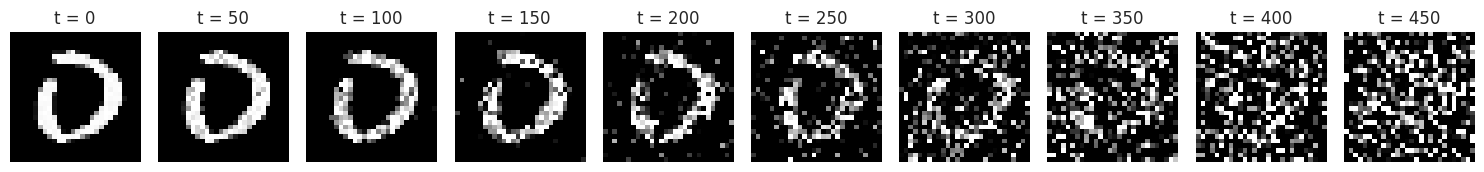

In [ ]:
image = next(iter(data_loader))[0]
Diffusion(unet, T=500, schedule_type="cosine").visualize_forward_process(image, num_images=10)

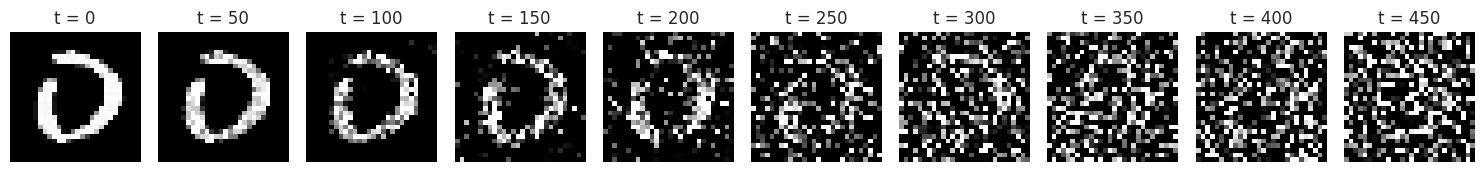

In [ ]:
Diffusion(unet, T=500, schedule_type="linear").visualize_forward_process(image, num_images=10)

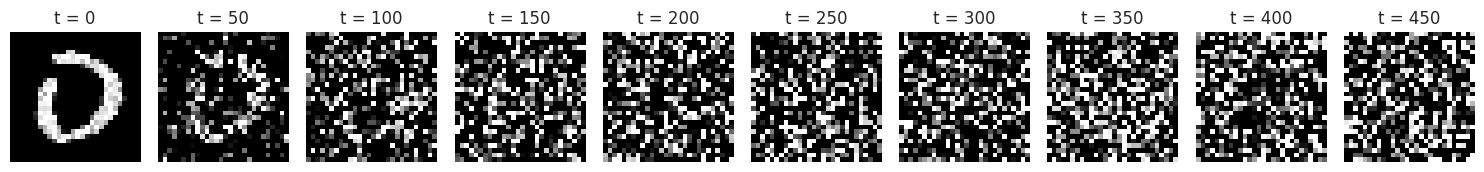

In [ ]:
Diffusion(unet, T=500, schedule_type="fixed").visualize_forward_process(image, num_images=10)

In [ ]:
train(data_loader, diffusion, unet, optim, num_epochs, model_title="unet", img_count=64)

FigureWidget({
    'data': [{'legendgroup': '1',
              'line': {'color': 'blue'},
              'name': 'MSELoss',
              'type': 'scatter',
              'uid': 'bd0103ae-76b1-4fa8-b5e1-5cb3db7826a0',
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'U-Net Loss',
                                'x': 0.225,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Generated Images',
                                'x': 0.775,
                                'xanchor': 'center',
           

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 0 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2 train:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 25 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 26 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 27 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 28 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 29 train:   0%|          | 0/938 [00:00<?, ?it/s]

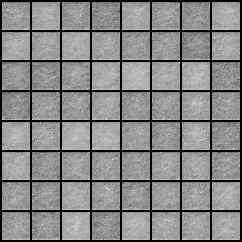

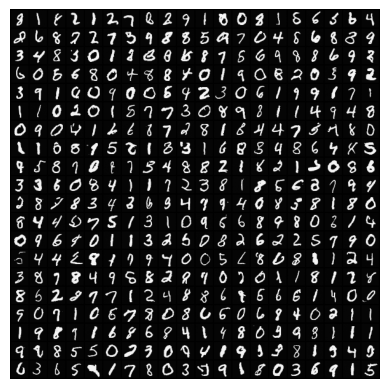

In [ ]:
visualize_plt_sample(diffusion, img_count=400)

### FID и IS

In [ ]:
def transform_for_inception(imgs):
    """Transform images to format suitable for inception model"""
    transform = transforms.Compose([
        transforms.Resize((299, 299)),
        lambda x: x.repeat(3, 1, 1) if x.shape[0] == 1 else x,
        transforms.Normalize([0.5]*3, [0.5]*3)
    ])
    return torch.stack([transform(img) for img in imgs])


def get_inception_activations(imgs, model, batch_size=32):
    """Get activations from latest layer of inception model"""
    model.eval()
    preds = []
    with torch.no_grad():
        for i in range(0, len(imgs), batch_size):
            batch = imgs[i:i+batch_size].to(device)
            pred = model(batch)
            preds.append(pred.detach().cpu())
    return torch.cat(preds, dim=0)


def calculate_FID(act1, act2):
    """FID metric for comparing real and fake image disctibutions"""
    mu1, sigma1 = act1.mean(dim=0), torch.cov(act1.T)
    mu2, sigma2 = act2.mean(dim=0), torch.cov(act2.T)
    diff = mu1 - mu2
    covmean = torch.tensor(scipy.linalg.sqrtm((sigma1 @ sigma2).numpy()).real)
    fid = diff.dot(diff) + torch.trace(sigma1 + sigma2 - 2 * covmean)
    return fid.item()


In [ ]:
def calculate_IS(activations, splits=10):
    """IS metric"""
    probs = F.softmax(activations, dim=1)
    split_scores = []
    for k in range(splits):
        part = probs[k * (len(probs) // splits): (k+1) * (len(probs) // splits)]
        p_y = part.mean(dim=0)
        kl_div = part * (torch.log(part + 1e-6) - torch.log(p_y + 1e-6))
        split_scores.append(kl_div.sum(dim=1).mean().item())
    return np.exp(np.mean(split_scores))

In [ ]:
inception = torchvision.models.inception_v3(pretrained=True, transform_input=False).to(device)
inception.fc = nn.Identity()
inception.eval()

real_images = transform_for_inception(transform_for_inception(next(iter(data_loader))[0]))
activations_real = get_inception_activations(real_images, inception)

fake_images = transform_for_inception(diffusion.sample(n=batch_size).cpu())
activations_fake = get_inception_activations(fake_images, inception)

# metric
fid_score = calculate_FID(activations_real, activations_fake)
activations_fake2 = get_inception_activations(fake_images, torchvision.models.inception_v3(pretrained=True).to(device))
inception_score = calculate_IS(activations_fake2)

print(f"FID: {fid_score}")
print(f"IS: {inception_score}")

FID: 598.1641845703125
IS: 1.9244069054270942


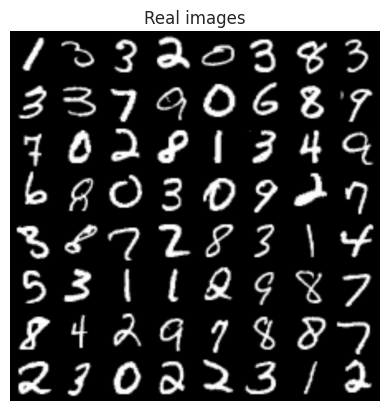

In [ ]:
plt.imshow(make_grid(real_images, nrow=int(np.sqrt(batch_size)), normalize=True).cpu().permute(1, 2, 0))
plt.grid(False)
plt.axis("off")
plt.title("Real images")
plt.show()

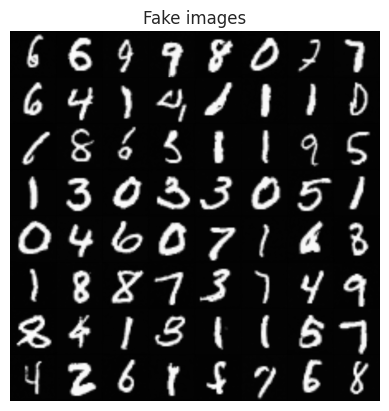

In [ ]:
plt.imshow(make_grid(fake_images, nrow=int(np.sqrt(batch_size)), normalize=True).cpu().permute(1, 2, 0))
plt.grid(False)
plt.axis("off")
plt.title("Fake images")
plt.show()

### Интерполяция

In [ ]:
z1 = torch.randn(1, 1, 28, 28).to(device)
z2 = torch.randn(1, 1, 28, 28).to(device)

# z1 = next(iter(data_loader))[0][0].to(device)
# z2 = next(iter(data_loader))[0][1].to(device)

alphas = torch.linspace(0, 1, steps=25).to(device)
z_interp = [(1 - alpha) * z1 + alpha * z2 for alpha in alphas]
z_interp = torch.cat(z_interp, dim=0)

interp_samples = []
diffusion.model.eval()
with torch.no_grad():
    for z in z_interp:
        z = z.unsqueeze(0)#.unsqueeze(0)
        x = z.clone()
        for t in reversed(range(diffusion.T)):
            t_tensor = torch.full((1,), t, dtype=torch.long, device=device)
            beta_t = diffusion.betas[t_tensor].view(-1, 1, 1, 1)
            alpha_t = diffusion.alphas[t_tensor].view(-1, 1, 1, 1)
            alpha_cumprod_t = diffusion.alphas_cumprod[t_tensor].view(-1, 1, 1, 1)
            noise_pred = diffusion.model(x, t_tensor)
            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = torch.zeros_like(x)
            coef1 = 1 / alpha_t.sqrt()
            coef2 = (1 - alpha_t) / (1 - alpha_cumprod_t).sqrt()
            x = coef1 * (x - coef2 * noise_pred) + beta_t.sqrt() * noise
        interp_samples.append(x.squeeze(0))

interp_samples = torch.stack(interp_samples, dim=0)

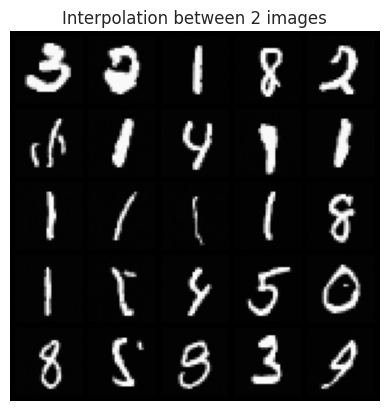

In [ ]:
plt.imshow(make_grid(interp_samples, nrow=5, normalize=True).cpu().permute(1, 2, 0))
plt.grid(False)
plt.axis("off")
plt.title("Interpolation between 2 images")
plt.show()

### Условная генерация

In [ ]:
class CondDiffusion:
    def __init__(self, model, T=1000, schedule_type="linear", device="cuda"):
        self.model = model
        self.T = T
        self.device = device

        self.betas = get_beta_schedule(schedule_type, self.T).to(device)
        self.alphas = (1. - self.betas).to(device)
        self.alphas_cumprod = torch.cumprod(self.alphas, dim=0).to(device)
        self.alphas_cumprod_prev = torch.cat([torch.tensor([1.0], device=device), self.alphas_cumprod[:-1]])

        self.sqrt_alphas_cumprod = torch.sqrt(self.alphas_cumprod).to(device)
        self.sqrt_one_minus_alphas_cumprod = torch.sqrt(1. - self.alphas_cumprod).to(device)

    def q_sample(self, x_start, t, noise=None):
        if noise is None:
            noise = torch.randn_like(x_start)
        sqrt_alpha_cumprod_t = self.sqrt_alphas_cumprod[t].view(-1, 1, 1, 1)
        sqrt_one_minus_alpha_cumprod_t = self.sqrt_one_minus_alphas_cumprod[t].view(-1, 1, 1, 1)
        return sqrt_alpha_cumprod_t * x_start + sqrt_one_minus_alpha_cumprod_t * noise

    def p_losses(self, x_0, t, labels, noise=None):
        if noise is None:
            noise = torch.randn_like(x_0)
        x_noisy = self.q_sample(x_0, t, noise)
        noise_pred = self.model(x_noisy, t, labels)
        return F.mse_loss(noise_pred, noise)

    @torch.no_grad()
    def sample(self, n, labels, img_size=(1, 28, 28)):
        img = torch.randn((n, *img_size)).to(self.device)
        for i in reversed(range(self.T)):
            t = torch.full((n,), i, dtype=torch.long, device=self.device)
            beta_t = self.betas[t].view(-1, 1, 1, 1)
            alpha_t = self.alphas[t].view(-1, 1, 1, 1)
            alpha_cumprod_t = self.alphas_cumprod[t].view(-1, 1, 1, 1)
            noise_pred = self.model(img, t, labels)
            if i > 0:
                noise = torch.randn_like(img)
            else:
                noise = torch.zeros_like(img)
            coef1 = 1 / alpha_t.sqrt()
            coef2 = (1 - alpha_t) / (1 - alpha_cumprod_t).sqrt()
            img = coef1 * (img - coef2 * noise_pred) + beta_t.sqrt() * noise
        return img

In [ ]:
class CondUNet(UNet):
    def __init__(self, *args, num_classes=10, time_emb_dim=256, **kwargs):
        super().__init__(*args, time_emb_dim=time_emb_dim, **kwargs)
        self.label_emb = nn.Embedding(num_classes, time_emb_dim)

    def forward(self, x, t, labels):
        t = t.to(x.device)
        t_emb = get_sinusoidal_embedding(t, self.time_mlp[0].in_features).to(x.device)
        labels_emb = self.label_emb(labels.to(x.device))
        t_emb = self.time_mlp(t_emb + labels_emb)  # сумма эмбеддингов времени и класса

        x = self.init_conv(x)
        skip_connections = []

        for block in self.downs:
            if isinstance(block, nn.ModuleList):
                for layer in block:
                    x = layer(x, t_emb) if isinstance(layer, ResBlock) else layer(x)
                skip_connections.append(x)
            else:
                x = block(x)

        x = self.bot1(x, t_emb)
        x = self.bot_attn(x)
        x = self.bot2(x, t_emb)

        for block in self.ups:
            if isinstance(block, nn.ModuleList):
                skip = skip_connections.pop()
                x = torch.cat([x, skip], dim=1)
                for layer in block:
                    x = layer(x, t_emb) if isinstance(layer, ResBlock) else layer(x)
            else:
                x = block(x)

        return self.final_conv(self.final_act(self.final_norm(x)))

In [ ]:
def generate_sample_cond(diffusion, labels, sample_size=64):
    """Generation from latent space"""
    diffusion.model.to(device)
    diffusion.model.eval()
    with torch.no_grad():
        sample = diffusion.sample(sample_size, labels, (1, 28, 28))
        img_grid = make_grid(sample, nrow=int(np.sqrt(sample_size)), normalize=True)
        return img_grid

In [ ]:
def train_cond(data_loader, diffusion,  model, optim, num_epochs, model_title="cond_unet", img_count=64):
    """Conditional diffusion model training"""
    losses_epochs = []
    labels_to_gen = None
    fig_widget = create_plot_widget()
    display(fig_widget)

    for epoch in tqdm(range(num_epochs)):
        model.train()
        total_loss = 0
        for x, labels in tqdm(data_loader, desc=f"Epoch {epoch} train", leave=False):
            x = x.to(device)
            labels = labels.to(device)
            t = torch.randint(0, diffusion.T, (x.size(0),), device=device)
            loss = diffusion.p_losses(x, t, labels)
            optim.zero_grad()
            loss.backward()
            optim.step()
            total_loss += loss.item()

            if labels_to_gen is None:
              labels_to_gen = labels

        losses_epochs.append(total_loss / len(data_loader))
        save_model_state(model, optim, model_title, epoch)

        img_tensor = generate_sample_cond(diffusion, labels_to_gen, img_count)
        save_image_epoch(img_tensor, epoch, model_title)
        update_plot_widget(fig_widget, losses_epochs, img_tensor)

In [ ]:
cond_unet = CondUNet()
cond_unet.to(device)
cond_optim = torch.optim.Adam(cond_unet.parameters(), lr=learning_rate)
cond_diffusion = CondDiffusion(cond_unet, T=T, schedule_type="cosine", device=device)

In [ ]:
train_cond(data_loader, cond_diffusion, cond_unet, cond_optim, num_epochs, model_title="cond_unet", img_count=64)

FigureWidget({
    'data': [{'legendgroup': '1',
              'line': {'color': 'blue'},
              'name': 'MSELoss',
              'type': 'scatter',
              'uid': '577fc786-944c-4b30-a10e-81d726c43f6c',
              'xaxis': 'x',
              'yaxis': 'y'}],
    'layout': {'annotations': [{'font': {'size': 16},
                                'showarrow': False,
                                'text': 'U-Net Loss',
                                'x': 0.225,
                                'xanchor': 'center',
                                'xref': 'paper',
                                'y': 1.0,
                                'yanchor': 'bottom',
                                'yref': 'paper'},
                               {'font': {'size': 16},
                                'showarrow': False,
                                'text': 'Generated Images',
                                'x': 0.775,
                                'xanchor': 'center',
           

  0%|          | 0/30 [00:00<?, ?it/s]

Epoch 0 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 1 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 2 train:   0%|          | 0/938 [00:00<?, ?it/s]

...

Epoch 25 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 26 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 27 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 28 train:   0%|          | 0/938 [00:00<?, ?it/s]

Epoch 29 train:   0%|          | 0/938 [00:00<?, ?it/s]